# Plotting

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from typing import List, Tuple, Optional


def _cell_to_numeric(maze: List[List]) -> np.ndarray:
    # Convert maze with mixed types to numeric array for display
    height = len(maze)
    width = len(maze[0])
    numeric_maze = np.zeros((height, width))

    cell_map = {
        0: 0,      # empty
        '.': 0,    # empty (alternative)
        '#': 1,    # wall
        1: 1,      # wall (alternate)
        'w': 1,    # wall (alternate)
        'r': 2,    # robot
        'R': 2,    # robot (alternate)
        'g': 3,    # goal
        'G': 3,    # goal (alternate)
        '@': 3,    # goal (alternate)
        'B': 4,    # block (treat as empty for visualization)
        'b': 4,    # block (alternate)
        'e': 5,    # elbow
    }

    for r in range(height):
        for c in range(width):
            cell = maze[r][c]
            numeric_maze[r][c] = cell_map.get(cell, 0)

    return numeric_maze


def plot_level(maze: List[List], title: str = "Sokoban Level", figsize: Tuple[int, int] = (8, 8)):
    # Plot a single sokoban level
    numeric_maze = _cell_to_numeric(maze)

    fig, ax = plt.subplots(figsize=figsize)

    # Create the base maze visualization
    cmap = plt.cm.colors.ListedColormap(['white', 'black', 'blue', 'red', 'brown', 'green'])
    im = ax.imshow(numeric_maze, cmap=cmap, origin='upper', vmin=0, vmax=5)

    # Add grid
    height, width = numeric_maze.shape
    ax.set_xticks(np.arange(-0.5, width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, height, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    ax.tick_params(which='minor', size=0)

    # Set main ticks
    ax.set_xticks(np.arange(0, width, 1))
    ax.set_yticks(np.arange(0, height, 1))

    # Add legend
    legend_elements = [
        patches.Patch(facecolor='white', edgecolor='black', label='Empty'),
        patches.Patch(facecolor='black', edgecolor='black', label='Wall'),
        patches.Patch(facecolor='blue', edgecolor='black', label='Robot'),
        patches.Patch(facecolor='red', edgecolor='black', label='Goal'),
        patches.Patch(facecolor='brown', edgecolor='black', label='Box'),
        patches.Patch(facecolor='green', edgecolor='black', label='Elbow (empty)')
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.0, 1.0))

    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    return fig, ax


def plot_multiple_levels(
    mazes: List[List[List]],
    titles: Optional[List[str]] = None,
    figsize: Tuple[int, int] = (15, 10)
):
    # Plot multiple sokoban levels in a grid
    n_mazes = len(mazes)
    cols = min(3, n_mazes)
    rows = (n_mazes + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    # Handle single subplot case
    if n_mazes == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, maze in enumerate(mazes):
        ax = axes[idx]
        numeric_maze = _cell_to_numeric(maze)

        cmap = plt.cm.colors.ListedColormap(['white', 'black', 'blue', 'red', 'brown', 'green'])
        ax.imshow(numeric_maze, cmap=cmap, origin='upper', vmin=0, vmax=5)

        # Add grid
        height, width = numeric_maze.shape
        ax.set_xticks(np.arange(-0.5, width, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, height, 1), minor=True)
        ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
        ax.tick_params(which='minor', size=0)

        ax.set_xticks(np.arange(0, width, 1))
        ax.set_yticks(np.arange(0, height, 1))

        if titles:
            ax.set_title(titles[idx], fontsize=11, fontweight='bold')
        else:
            ax.set_title(f'Level {idx + 1}', fontsize=11, fontweight='bold')

    # Hide unused subplots
    for idx in range(n_mazes, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    return fig, axes

# Artificial potential fields approach

Path stuck at (11, 8) after 26 steps.
Goal NOT reached in 26 steps.


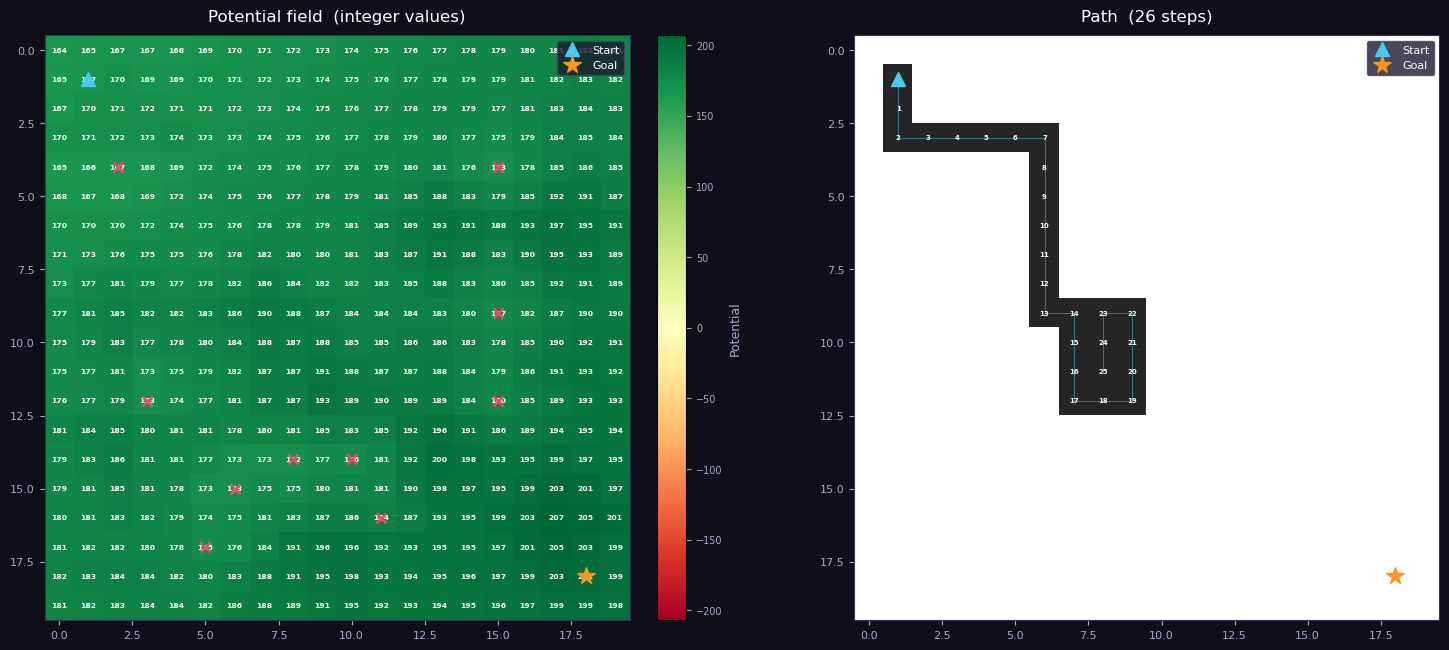

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass
from typing import List, Tuple, Optional
import random


@dataclass
class DiscreteField:
    row: int
    col: int

    # Positive weight = attractor, negative weight = repulsor
    weight: int
    
    # Potential decreases by this amount per step of Manhattan distance
    decay: int = 1

    def radius(self) -> int:
        # The field has zero influence beyond this many cells
        return self.weight // self.decay

    def contribution(self, r: int, c: int) -> int:
        dist = abs(r - self.row) + abs(c - self.col)  # Manhattan distance
        magnitude = max(0, abs(self.weight) - dist * self.decay)
        return magnitude if self.weight >= 0 else -magnitude


def compute_potential_grid(
    rows: int,
    cols: int,
    fields: List[DiscreteField],
) -> np.ndarray:
    # Build index arrays once, then vectorise over all fields
    r_idx, c_idx = np.mgrid[0:rows, 0:cols]
    grid = np.zeros((rows, cols), dtype=np.int32)
    for f in fields:
        manhattan = np.abs(r_idx - f.row) + np.abs(c_idx - f.col)
        magnitude = np.maximum(0, abs(f.weight) - manhattan * f.decay).astype(np.int32)
        grid += magnitude if f.weight > 0 else -magnitude
    return grid


def find_path(
    grid: np.ndarray,
    start: Tuple[int, int],
    goal: Tuple[int, int],
    max_steps: Optional[int] = None,
) -> List[Tuple[int, int]]:
    rows, cols = grid.shape
    if max_steps is None:
        max_steps = rows * cols

    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # up / down / left / right
    path = [start]
    visited = {start}
    current = start

    while current != goal and len(path) <= max_steps:
        r, c = current
        candidates = [
            (r + dr, c + dc)
            for dr, dc in directions
            if 0 <= r + dr < rows
            and 0 <= c + dc < cols
            and (r + dr, c + dc) not in visited
        ]
        if not candidates:
            print(f"Path stuck at {current} after {len(path)} steps.")
            break
        best = max(candidates, key=lambda rc: grid[rc[0], rc[1]])
        path.append(best)
        visited.add(best)
        current = best

    status = "Goal reached" if current == goal else "Goal NOT reached"
    print(f"{status} in {len(path)} steps.")
    return path


def place_random_repulsors(
    rows: int,
    cols: int,
    count: int,
    start: Tuple[int, int],
    goal: Tuple[int, int],
    weight: int = -60,
    decay: int = 3,
    margin: int = 2,
    seed: Optional[int] = None,
) -> List[DiscreteField]:
    rng = random.Random(seed)
    forbidden = {start, goal}
    repulsors: List[DiscreteField] = []
    attempts = 0
    while len(repulsors) < count and attempts < count * 30:
        r = rng.randint(margin, rows - margin - 1)
        c = rng.randint(margin, cols - margin - 1)
        if (r, c) not in forbidden:
            repulsors.append(
                DiscreteField(row=r, col=c, weight=weight, decay=decay)
            )
            forbidden.add((r, c))
        attempts += 1
    return repulsors


def place_repulsors_on_edges(
    rows: int,
    cols: int,
    start: Tuple[int, int],
    goal: Tuple[int, int],
    weight: int = 60,
    decay: int = 3,
) -> List[DiscreteField]:
    
    forbidden = {start, goal}
    repulsors: List[DiscreteField] = []
    
    for r in range(rows):
        targets = [(r, 0), (r, cols-1)]
        for target in targets:
            if target not in forbidden:
                repulsors.append(
                    DiscreteField(row=target[0], col=target[1], weight=weight, decay=decay)
                )

    for c in range(cols):
        targets = [(0, c), (rows - 1, c)]
        for target in targets:
            if target not in forbidden:
                repulsors.append(
                    DiscreteField(row=target[0], col=target[1], weight=weight, decay=decay)
                )

    return repulsors


def visualize(
    grid: np.ndarray,
    path: List[Tuple[int, int]],
    fields: List[DiscreteField],
    start: Tuple[int, int],
    goal: Tuple[int, int],
    save_path: Optional[str] = None,
) -> None:
    rows, cols = grid.shape
    repulsors = [f for f in fields if f.weight < 0]
    attractors = [f for f in fields if f.weight > 0]
 
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.patch.set_facecolor("#0f0f1a")
 
    # Draw grid lines
    def draw_grid(ax, nrows, ncols):
        for x in range(ncols + 1):
            ax.axvline(x - 0.5, color="#333355", linewidth=0.4, zorder=1)
        for y in range(nrows + 1):
            ax.axhline(y - 0.5, color="#333355", linewidth=0.4, zorder=1)
 
    # Left panel: potential field with value annotations
    ax1 = axes[0]
    ax1.set_facecolor("#0f0f1a")
 
    vabs = np.max(np.abs(grid))
    im = ax1.imshow(
        grid, cmap="RdYlGn", origin="upper", aspect="equal",
        vmin=-vabs, vmax=vabs, zorder=2,
    )
    cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
    cbar.ax.yaxis.set_tick_params(color="#aaaacc")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#aaaacc", fontsize=7)
    cbar.set_label("Potential", color="#aaaacc", fontsize=9)
 
    draw_grid(ax1, rows, cols)
 
    # Annotate every cell with its integer value
    for r in range(rows):
        for c in range(cols):
            val = int(grid[r, c])
            # Choose text colour based on cell brightness
            norm_val = (val + vabs) / (2 * vabs + 1e-9)
            text_color = "black" if 0.3 < norm_val < 0.7 else "white"
            ax1.text(
                c, r, str(val),
                ha="center", va="center",
                fontsize=5.5, color=text_color,
                fontweight="bold", zorder=4,
            )
 
    # Mark repulsor centres with an X
    for f in repulsors:
        ax1.plot(f.col, f.row, "x", color="#ff4466",
                 markersize=7, markeredgewidth=1.8, zorder=5)
 
    ax1.plot(start[1], start[0], "^", color="#4cc9f0",
             markersize=10, zorder=6, label="Start", linestyle="None")
    ax1.plot(goal[1], goal[0], "*", color="#f8961e",
             markersize=13, zorder=6, label="Goal", linestyle="None")
 
    ax1.set_title("Potential field  (integer values)", color="white", fontsize=12, pad=10)
    ax1.tick_params(colors="#aaaacc", labelsize=8)
    for sp in ax1.spines.values():
        sp.set_edgecolor("#333355")
    ax1.legend(facecolor="#1a1a2e", edgecolor="#444466",
               labelcolor="white", fontsize=8)
 
    # Right panel: black-and-white path grid with step numbers
    ax2 = axes[1]
    ax2.set_facecolor("#0f0f1a")
 
    # Pure B&W background
    bw = np.ones((rows, cols), dtype=np.float32)  # white = empty
    for r, c in path:
        bw[r, c] = 0.15  # near-black path cells
 
    ax2.imshow(bw, cmap="gray", origin="upper", aspect="equal",
               vmin=0.0, vmax=1.0, zorder=2)
    draw_grid(ax2, rows, cols)
 
    # Number every step along the path
    for step, (r, c) in enumerate(path):
        ax2.text(
            c, r, str(step),
            ha="center", va="center",
            fontsize=5, color="white", fontweight="bold", zorder=5,
        )
 
    # Thin connecting line for readability
    if len(path) > 1:
        pr, pc = zip(*path)
        ax2.plot(pc, pr, color="#4cc9f0", linewidth=0.7, alpha=0.5, zorder=3)
 
    ax2.plot(start[1], start[0], "^", color="#4cc9f0",
             markersize=10, zorder=6, label="Start", linestyle="None")
    ax2.plot(goal[1], goal[0], "*", color="#f8961e",
             markersize=13, zorder=6, label="Goal", linestyle="None")
 
    ax2.set_title(f"Path  ({len(path)} steps)", color="white", fontsize=12, pad=10)
    ax2.tick_params(colors="#aaaacc", labelsize=8)
    for sp in ax2.spines.values():
        sp.set_edgecolor("#333355")
    ax2.legend(facecolor="#1a1a2e", edgecolor="#444466",
               labelcolor="white", fontsize=8)
 
    plt.tight_layout(pad=2.5)
 
    if save_path:
        plt.savefig(save_path, dpi=180, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"Saved to {save_path}")
 
    plt.show()



ROWS, COLS = 20, 20
START = (1, 1)
GOAL = (18, 18)

# Goal field: high weight, low decay → influence covers the full grid.
# radius = 200 // 1 = 200 cells, well beyond any 20x20 diagonal.
goal_field = DiscreteField(
    row=GOAL[0], col=GOAL[1],
    weight=200,
    decay=1,
)

# Repulsors: moderate weight, high decay → tight radius of 60//3 = 20 cells.
repulsors = place_random_repulsors(
    rows=ROWS, cols=COLS,
    count=10,
    start=START, goal=GOAL,
    weight=-10,
    decay=3,
)

attractors = place_random_repulsors(
    rows=ROWS, cols=COLS,
    count=10,
    start=START, goal=GOAL,
    weight=10, 
    decay=3
)

all_fields = [goal_field] + repulsors + attractors
grid = compute_potential_grid(ROWS, COLS, all_fields)
path = find_path(grid, START, GOAL)

visualize(
    grid=grid,
    path=path,
    fields=all_fields,
    start=START,
    goal=GOAL,
)

# Loop-Erased Random Walk

In [ ]:
import random

def generate_waypoints(grid_w, grid_h, start, goal, spread=0.5):
    """
    Farthest-Point Sampling: each new waypoint is drawn from a distribution
    weighted by min distance² to all already-chosen points.
    This maximizes spatial spread across the grid.
    """
    count = min(round(spread * 6), (grid_w * grid_h) // 8)
    if count == 0:
        return []

    chosen = [start, goal]
    waypoints = []

    for _ in range(count):
        candidates = [
            (x, y)
            for x in range(grid_w) for y in range(grid_h)
            if (x, y) not in chosen
        ]
        if not candidates:
            break

        # Weight by squared min-distance from any chosen point
        weights = [min(abs(x-cx)+abs(y-cy) for cx,cy in chosen)**2 for x,y in candidates]
        [wp] = random.choices(candidates, weights=weights, k=1)
        waypoints.append(wp)
        chosen.append(wp)

    # Greedy nearest-neighbor ordering from start
    ordered, remaining, cur = [], list(waypoints), start
    while remaining:
        nearest = min(remaining, key=lambda p: abs(p[0]-cur[0])+abs(p[1]-cur[1]))
        ordered.append(nearest)
        remaining.remove(nearest)
        cur = nearest

    return ordered


def lerw_path(grid_w, grid_h, start, goal, entropy=0.3, spread=0.3):
    """
    Loop-Erased Random Walk with waypoints for full-grid coverage.

    Args:
        entropy : 0.0 = greedy straight line, 1.0 = fully random local walk
        spread  : 0.0 = direct (original behavior), 1.0 = many waypoints, full coverage
    """
    def neighbors(x, y):
        return [(x+dx, y+dy) for dx, dy in ((0,1),(0,-1),(1,0),(-1,0))
                if 0 <= x+dx < grid_w and 0 <= y+dy < grid_h]

    def biased_step(cell, target):
        opts = neighbors(*cell)
        if random.random() > entropy:
            return min(opts, key=lambda p: abs(p[0]-target[0])+abs(p[1]-target[1]))
        return random.choice(opts)

    def current_target_idx(targets, visited):
        return next((i for i, t in enumerate(targets) if t not in visited), len(targets))

    waypoints = generate_waypoints(grid_w, grid_h, start, goal, spread)
    targets = waypoints + [goal]

    path = [start]
    visited = {start: 0}

    while True:
        ti = current_target_idx(targets, visited)
        if ti >= len(targets):
            break

        current = path[-1]
        nxt = biased_step(current, targets[ti])

        if nxt in visited:
            # Loop erasure — may un-reach a previously visited waypoint
            loop_idx = visited[nxt]
            for cell in path[loop_idx + 1:]:
                del visited[cell]
            path = path[:loop_idx + 1]
        else:
            visited[nxt] = len(path)
            path.append(nxt)

    return path


path = lerw_path(20, 20, start=(0,0), goal=(19,19), entropy=0.9)
print(f"Path length: {len(path)} cells")

Path length: 68 cells


# Level generator

In [84]:
from typing import Tuple, List, Set
import random


"""
Base algorithm:
- We start from an empty grid with borders.
- We define robot position and goal position.
- We build a road connecting the two. The road might have an arbitrary number 
    of turns (in accordance with the size of the grid) 
- We enhance this road with "elbows", that the agent can use to push the box 
    towards the goal

This generates playable levels but the problem is that they are too simplistic:
there always is a single way leading to the goal, no complex cell arrangments, 
no crossing paths...

Enhanced algorithm:
- We iterate the above procedure a given number of times. This ensures 
    crossing paths and non-trivial global solutions.
- We apply an "erosion" step: we randomly remove some cells. This increase the 
    complexity of the maxe as the agent can now perform unnecessary actions
    and therefore produce non-optimal solutions.
- We apply a "deposition" step: we randomly add some cells. This should be done
    with criterion: adding cells could block the only path leading to the solution
    (even if we iterate the procedure, it could happen that for example the terminal
    part of the paths is shared across iterations and a new cell ends up blocking 
    all of them at the same time). We can add a block only if [???]
"""



"""
Cell encoding:
  1 / 'W' / 'w': Wall
  0:             Empty cell
  'r' / 'R':     Valid robot reset position
  'g' / 'G':     Valid goal position
"""
ENCODING = {
    'WALL': '#',
    'EMPTY': '.',
    'ROBOT': 'r',
    'GOAL': '@',
    'BLOCK': 'b',
    'ELBOW': 'e'
}

"""
Directions
"""
DIRECTIONS = {
    'UP': (-1, 0),
    'DOWN': (1, 0),
    'LEFT': (0, -1),
    'RIGHT': (0, 1)
}

"""
Fractions of the grid dimension used to define the spawn region.

These values limit random position selection to a sub-region of the
original grid. We will anchor it to the first and fourth quadrants
(this will be clear when the constants are actually used)

    row in [0, SPAWN_AREA_FRACTION_H * H)
    col in [0, SPAWN_AREA_FRACTION_W * W)

where H and W are the array height and width, SPAWN_AREA_FRACTION_H and 
SPAWN_AREA_FRACTION_W are the fractions for height and width respectively.

The resulting spawn region covers (SPAWN_AREA_FRACTION_H * SPAWN_AREA_FRACTION_W) 
of the total area (e.g. SAF_W=0.2, SAF_H=0.2 -> SPAWN_REGION=4%).
"""
ROBOT_SPAWN_AREA_FRACTION_W = 0.2
ROBOT_SPAWN_AREA_FRACTION_H = 0.2

# For the goal we will then
GOAL_SPAWN_AREA_FRACTION_W = 0.5
GOAL_SPAWN_AREA_FRACTION_H = 0.5

assert GOAL_SPAWN_AREA_FRACTION_W + ROBOT_SPAWN_AREA_FRACTION_W <= 1
assert GOAL_SPAWN_AREA_FRACTION_H + ROBOT_SPAWN_AREA_FRACTION_H <= 1

"""
Maximum and minimum grid sizes. The minimum takes into account that:
- we need to have at least a 1-cell border around the maze 
    (2 cells width/height reserved for this)
- we need to leave space for the path elbows
    (2 cells width/height reserved for this)
This means the effective minimum size of the maze will be:

    MIN_GRID_WIDTH - 4
    MIN_GRID_HEIGHT - 4

"""
MIN_GRID_WIDTH, MAX_GRID_WIDTH = 12, 30
MIN_GRID_HEIGHT, MAX_GRID_HEIGHT = 12, 30

"""
Enhanced algorithm parameters
"""
NUM_ROAD_ITERATIONS = 3
EROSION_STRENGTH = 0.05
DEPOSITION_STRENGTH = 0.05


def pretty_print(maze: List[List]):

    for y in range(len(maze)):
        for x in range(len(maze[y])):
            print(maze[y][x], end='')
        print()
    print()


def maze_to_string(maze: List[List]) -> str:
    result = []

    for y in range(len(maze)):
        row = []
        for x in range(len(maze[y])):
            row.append(str(maze[y][x]))
        result.append(''.join(row))

    return '\n'.join(result) + '\n'


def is_empty(maze: List[List], row: int, col: int):
    if row < 0 or row >= len(maze) or col < 0 or col >= len(maze[0]):
        return False
    return maze[row][col] == ENCODING['EMPTY']


def is_wall(maze: List[List], row: int, col: int):
    if row < 0 or row >= len(maze) or col < 0 or col >= len(maze[0]):
        return False
    return maze[row][col] == ENCODING['WALL']


def manhattan_distance(start: Tuple[int, int], end: Tuple[int, int]):
    """Simple Manhattan distance heuristic"""
    return abs(start[0] - end[0]) + abs(start[1] - end[1])


def get_random_empty_cell(maze: List[List], avoid: Set[Tuple[int, int]]=None):
    """
    Returns a random empty cell in the specified range
    
    Args:
        maze: the maze, duh
        avoid: set of cells we should avoid
    """

    if not avoid:
        avoid = set()

    height, width = len(maze), len(maze[0])

    # Gather all cells
    cells = {(r, c) for r in range(0, height) for c in range(0, width)}

    # Remove non-empty cells
    cells = {(r, c) for (r, c) in cells if is_empty(maze, r, c)}

    # Remove cells in avoid set
    cells = {(r, c) for (r, c) in cells if (r, c) not in avoid}

    if len(cells) == 0:
        raise ValueError("Something weng wrong, check the maze")

    # Return a random cell among the empty ones
    return random.sample(list(cells), 1)[0]


def add_elbows(path: List[Tuple]):
    """
    Add elbows to the path:

    +--+--+--+--+--+--+--+--+--+--+
    |  |ss|  |  |  |  |  |  |  |  |
    +--+--+--+--+--+--+--+--+--+--+
    |  |pp|  |  |  |  |  |ee|ee|  |
    +--+--+--+--+--+--+--+--+--+--+
    |  |pp|pp|pp|pp|pp|pp|pp|pp|  |
    +--+--+--+--+--+--+--+--+--+--+
    |  |pp|  |  |  |  |  |  |pp|  |
    +--+--+--+--+--+--+--+--+--+--+
    |  |pp|  |  |  |  |  |  |pp|..|
    +--+--+--+--+--+--+--+--+--+--+
    |ee|pp|  |  |  |  |  |  |  |  |     e.g.    p0 = (5, 1)
    +--+--+--+--+--+--+--+--+--+--+             p1 = (6, 1) 
    |ee|pp|pp|pp|pp|pp|pp|pp|pp|..|             p2 = (6, 2)
    +--+--+--+--+--+--+--+--+--+--+             d1 = (6-5, 1-1) = (1, 0) -> down
                                                d2 = (6-6, 2-1) = (0, 1) -> right

    - ss: start
    - pp: path
    - ee: elbow

    Note: elbow always involves only p0 and p1
    """

    assert len(path) >= 2, "What kind of path did you found you dumb ass"

    def has_turned(p0: Tuple[int, int], p1: Tuple[int, int], p2: Tuple[int, int]):
        x0, y0 = p0
        x1, y1 = p1
        x2, y2 = p2

        # Direction vectors
        d1 = (x1 - x0, y1 - y0)
        d2 = (x2 - x1, y2 - y1)

        return d1 != d2

    def get_elbow_cells(p0: Tuple[int, int], p1: Tuple[int, int], p2: Tuple[int, int]):
        x0, y0 = p0
        x1, y1 = p1
        x2, y2 = p2

        # d2 = (x2 - x1, y2 - y1)
        # e0 = p0 - d2
        # e1 = p1 - d2

        e0 = (x0 - x2 + x1, y0 - y2 + y1)
        e1 = (x1 - x2 + x1, y1 - y2 + y1) 
        
        return [e0, e1]

    elbow_cells = []
    for i in range(1, len(path) - 1):
        p0 = path[i-1]
        p1 = path[i]
        p2 = path[i+1]
        if has_turned(p0, p1, p2):
            elbow_cells.extend(get_elbow_cells(p0, p1, p2))

    return elbow_cells


def get_box_candidate_positions(path):
    """
    Get candidate box positions. To ensure solvability, we put the box either in:
    - a corridor
    - the elbow joint
    """

    assert len(path) >= 2, "What kind of path did you found you dumb ass"

    def has_turned(p0: Tuple[int, int], p1: Tuple[int, int], p2: Tuple[int, int]):
        x0, y0 = p0
        x1, y1 = p1
        x2, y2 = p2

        # Direction vectors
        d1 = (x1 - x0, y1 - y0)
        d2 = (x2 - x1, y2 - y1)

        return d1 != d2

    def get_elbow_cells(p0: Tuple[int, int], p1: Tuple[int, int], p2: Tuple[int, int]):
        x0, y0 = p0
        x1, y1 = p1
        x2, y2 = p2

        # d2 = (x2 - x1, y2 - y1)
        # e0 = p0 - d2
        # e1 = p1 - d2

        e0 = (x0 - x2 + x1, y0 - y2 + y1)
        e1 = (x1 - x2 + x1, y1 - y2 + y1) 
        
        return [e0, e1]

    candidate_box_positions = []
    for i in range(1, len(path) - 1):
        p0 = path[i-1]
        p1 = path[i]
        p2 = path[i+1]
        if has_turned(p0, p1, p2):
            candidate_box_positions.append(p1)
    
    return candidate_box_positions


def lerw_waypoints(
        maze: List[List],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        spread: float = 0.3,
    ):
    """
    Farthest-Point Sampling: each new waypoint is drawn from a distribution
    weighted by min distance^2 to all already-chosen points.
    This maximizes spatial spread across the grid.
    """

    height, width = len(maze), len(maze[0])

    # TODO check this formula
    count = min(round(spread * 6), (width * height) // 8)

    if count == 0:
        return []

    chosen = [start, goal]
    waypoints = []

    for _ in range(count):
        candidates = [
            (x, y)
            for x in range(width) for y in range(height)
            if (x, y) not in chosen
        ]
        if not candidates:
            break

        # Weight by squared min-distance from any chosen point
        weights = [min(abs(x - cx) + abs(y - cy) for cx,cy in chosen)**2 for x,y in candidates]
        [wp] = random.choices(candidates, weights=weights, k=1)
        waypoints.append(wp)
        chosen.append(wp)

    # Greedy nearest-neighbor ordering from start
    ordered, remaining, cur = [], list(waypoints), start
    while remaining:
        nearest = min(remaining, key=lambda p: abs(p[0]-cur[0])+abs(p[1]-cur[1]))
        ordered.append(nearest)
        remaining.remove(nearest)
        cur = nearest

    return ordered


def lerw_path(
        maze: List[List], 
        start: Tuple[int, int], 
        goal: Tuple[int, int],
        entropy: float=0.3,
        spread: float=0.3
    ):
    """
    Loop-Erased Random Walk with waypoints for full-grid coverage.

    Args:
        entropy: 0.0 = greedy straight line, 1.0 = fully random local walk
        spread: 0.0 = direct (original behavior), 1.0 = many waypoints, full coverage
    """

    height, width = len(maze), len(maze[0])

    def neighbors(x, y):
        return [(x + dx, y + dy) for dx, dy in ((0,1), (0,-1), (1,0), (-1,0))
                if 0 <= x + dx < width and 0 <= y + dy < height]

    def biased_step(cell, target):
        opts = neighbors(*cell)
        if random.random() > entropy:
            return min(opts, key=lambda p: abs(p[0]-target[0])+abs(p[1]-target[1]))
        return random.choice(opts)

    def current_target_idx(targets, visited):
        return next((i for i, t in enumerate(targets) if t not in visited), len(targets))

    waypoints = lerw_waypoints(maze, start, goal, spread)
    targets = waypoints + [goal]

    path = [start]
    visited = {start: 0}

    while True:
        ti = current_target_idx(targets, visited)
        if ti >= len(targets):
            break

        current = path[-1]
        nxt = biased_step(current, targets[ti])

        if nxt in visited:
            loop_index = visited[nxt]
            for cell in path[loop_index + 1:]:
                del visited[cell]
            path = path[:loop_index + 1]
        else:
            visited[nxt] = len(path)
            path.append(nxt)

    return path


def apply_erosion(maze: List[List]):
    """Randomly remove walls to increase complexity and open up the maze"""

    height, width = len(maze), len(maze[0])
    num_cells_to_erode = int(height * width * EROSION_STRENGTH)
 
    while num_cells_to_erode > 0:

        # Pick a random cell
        r = random.randint(0, height - 1)
        c = random.randint(0, width - 1)

        if maze[r][c] == ENCODING['EMPTY']:
            continue
            
        if maze[r][c] == ENCODING['ROBOT']:
            continue

        if maze[r][c] == ENCODING['GOAL']:
            continue
 
        # Check all possible neighbors
        neighbors = {(r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)}

        # Keep only the existing ones
        neighbors = set([neighbor for neighbor in neighbors if neighbor[0] < height and neighbor[1] < width])

        num_empty_neighbors = sum([1 if maze[neighbor[0]][neighbor[1]] == ENCODING['EMPTY'] else 0 for neighbor in neighbors])

        # Accept the cell only if a neighbor is empty
        # We can even be more restrictive and keep only cells with at least 2 empty neighbors
        if num_empty_neighbors < 1:
            continue

        # Finally, erosion could happen
        maze[r][c] = ENCODING['EMPTY']

        # If erosion successful, decrement counter
        num_cells_to_erode -= 1


def apply_deposition(maze: List[List]):
    raise ValueError("Not implemented")


def add_borders(maze: List[List]):
    """Add wall borders around the maze"""
    
    height, width = len(maze), len(maze[0])
    new_height, new_width = height + 2, width + 2
 
    new_maze = [[ENCODING['EMPTY'] for _ in range(new_width)] for _ in range(new_height)]

    # Top and bottom borders
    for c in range(new_width):
        new_maze[0][c] = ENCODING['WALL']
        new_maze[new_height - 1][c] = ENCODING['WALL']
 
    # Left and right borders
    for r in range(new_height):
        new_maze[r][0] = ENCODING['WALL']
        new_maze[r][new_width - 1] = ENCODING['WALL']

    # Copy old maze into new one
    for c in range(width):
        for r in range(height):
            new_maze[c + 1][r + 1] = maze[c][r]

    return new_maze


def generate_maze(
        height: int, 
        width: int, 
        erosion: bool = False,
        deposition: bool = False,
        **kwargs
    ) -> List[List]:
    """
    Generate a random maze using recursive backtracking. 
    The maze will feature a single block and a single goal position.
    """

    assert MIN_GRID_WIDTH <= width <= MAX_GRID_WIDTH, f"Maze width out of bounds({width}), should be {MIN_GRID_WIDTH} <= x <= {MAX_GRID_WIDTH}."
    assert MIN_GRID_HEIGHT <= height <= MAX_GRID_HEIGHT, f"Maze height out of bounds ({height}), should be {MIN_GRID_HEIGHT} <= y <= {MAX_GRID_HEIGHT}."

    full_width, full_height = width, height
    workable_width, workable_height = width - 4, height - 4

    # Generate a grid full of wall cells 
    full_maze = [[ENCODING['WALL'] for _ in range(full_width)] for _ in range(full_height)]
    workable_maze = [[ENCODING['WALL'] for _ in range(workable_width)] for _ in range(workable_height)]

    # Define robot position
    robot_x = int(random.random() * ROBOT_SPAWN_AREA_FRACTION_W * workable_width)
    robot_y = int(random.random() * ROBOT_SPAWN_AREA_FRACTION_H * workable_height)
    robot_position = (robot_x, robot_y)
    workable_maze[robot_x][robot_y] = ENCODING['ROBOT']

    # Define goal position
    goal_x = workable_width - int(random.random() * GOAL_SPAWN_AREA_FRACTION_W * workable_width) - 1
    goal_y = workable_height - int(random.random() * GOAL_SPAWN_AREA_FRACTION_H * workable_height) - 1
    goal_position = (goal_x, goal_y)
    workable_maze[goal_x][goal_y] = ENCODING['GOAL']

    # Build roads connecting start to goal
    paths = []
    for _ in range(NUM_ROAD_ITERATIONS):
        path = lerw_path(workable_maze, robot_position, goal_position, **kwargs)
        paths.append(path)

    # Get elbow cells
    elbows = []
    for path in paths:
        elbows.append(add_elbows(path))

    # Get positions where we can put the box
    boxes = []
    for path in paths:
        boxes.append(get_box_candidate_positions(path))

    # Dump all the stuff on the new maze
    full_maze[robot_x + 2][robot_y + 2] = ENCODING['ROBOT']
    full_maze[goal_x + 2][goal_y + 2] = ENCODING['GOAL']

    path_cells = set([cell for path in paths for cell in path])
    elbow_cells = set([cell for elbow in elbows for cell in elbow])
    box_cells = set([cell for box in boxes for cell in box]) - {robot_position} - {goal_position}
    cells = path_cells.union(elbow_cells)

    for cell in cells:
        if cell != goal_position and cell != robot_position:
            row, col = cell
            if cell in path_cells:
                full_maze[row + 2][col + 2] = ENCODING['EMPTY']
            else:
                full_maze[row + 2][col + 2] = ENCODING['ELBOW']

    # Apply erosion. This does not invalidate any solution to the problem,
    # it just adds maze complexity
    if erosion:
        apply_erosion(full_maze)

    # Apply deposition
    if deposition:
        apply_deposition(full_maze)

    # Any free cell at this point is a candidate for the block,
    # but we need to carefully analyze where to put it as this can
    # invalidate the solution.
    # Solution: place the block on p1 or in corridors
    #       (we know for sure we can push the box from there)
    # block_x, block_y = get_random_empty_cell(maze, avoid=elbow_cells)
    block_x, block_y = random.sample(sorted(box_cells), 1)[0]
    block_position = (block_x, block_y)
    if block_position == (-1, -1):
        raise ValueError(f"Cannot place block, check the maze.")
    full_maze[block_x + 2][block_y + 2] = ENCODING['BLOCK']
        
    # Enforce borders (erosion could breach the maze)
    for r in range(full_height):
        full_maze[r][0] = ENCODING['WALL']
        full_maze[r][full_width - 1] = ENCODING['WALL']

    for c in range(full_width):
        full_maze[0][c] = ENCODING['WALL']
        full_maze[full_height - 1][c] = ENCODING['WALL']

    return full_maze


maze = generate_maze(12, 12)
pretty_print(maze)

############
###eee##ee##
##r...#e.b##
##.#..#e..##
##.e..e#..##
#e.e......##
#e........##
####e..e.@##
####e.....##
#######eee##
############
############



(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'Sokoban Level'}>)

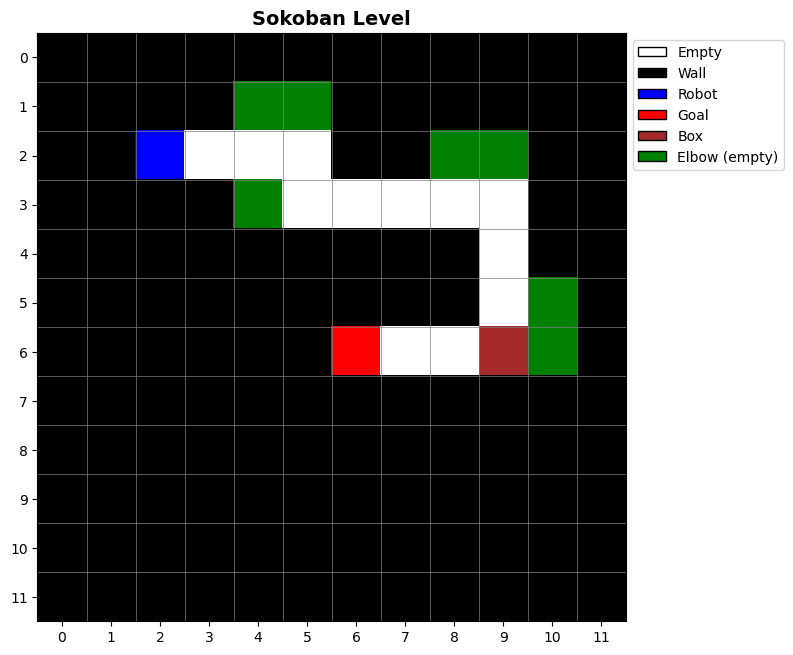

In [61]:
maze = generate_maze(12, 12, erosion=False)
plot_level(maze)

# Check solvability

In [38]:
# !pip install --pre unified-planning
!git clone https://github.com/speckdavid/unified-planning
!pip install unified-planning/

!pip install up-symk

Cloning into 'unified-planning'...
remote: Enumerating objects: 22307, done.
remote: Total 22307 (delta 0), reused 0 (delta 0), pack-reused 22307 (from 1)
Receiving objects: 100% (22307/22307), 11.90 MiB | 256.00 KiB/s, done.
Resolving deltas: 100% (16986/16986), done.
Processing ./unified-planning
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for unified_planning: filename=unified_planning-0.6.0.382.dev1-py3-none-any.whl size=646868 sha256=9d0e77a5c420eec2046196da11edbe4dcaee484b07b62e55cf0fe32c2e1daf3f
  Stored in directory: /home/daniel/.cache/pip/wheels/9b/7f/73/6070cb4fad88a71a432ace7b52bf4bd79d96f2fb0045e5a181
Successfully built unified_planning
  Attempting uninstall: unified_planning
    Found existing installation: unified_planning 0.6.0.382.dev1
    Uninstalling unified_planning-0.6.0.382.dev1:
      Successfully uninstalled unified_planning-0.6.0.382.dev1


In [39]:
import unified_planning as up
import up_symk
from unified_planning.shortcuts import *
from unified_planning.io import PDDLWriter, PDDLReader

In [51]:
"""
Use same encoding as above

ENCODING = {
    'WALL': '#',
    'EMPTY': '.',
    'ROBOT': 'r',
    'GOAL': '@',
    'BLOCK': 'b',
    'ELBOW': 'e'
}
"""

def create_sokoban_problem(level, with_axioms=False):
    problem = up.model.Problem("sokoban")
    
    loc = UserType("location")

    has_player, has_box, adjacent, adjacent_2, can_reach = (
        up.model.Fluent("has_player", BoolType(), l=loc),
        up.model.Fluent("has_box", BoolType(), l=loc),
        up.model.Fluent("adjacent", BoolType(), l1=loc, l2=loc),
        up.model.Fluent("adjacent_2", BoolType(), l1=loc, l2=loc),
        up.model.Fluent("can_reach", DerivedBoolType(), l=loc) if with_axioms else None,
    )

    for fluent in [has_player, has_box, adjacent, adjacent_2, can_reach]:
        if fluent:
            problem.add_fluent(fluent, default_initial_value=False)

    if with_axioms:
        # Axiom 1
        a1 = up.model.Axiom("reach-axiom-1", l=loc)
        a1.set_head(can_reach(a1.parameters[0]))
        a1.add_body_condition(has_player(a1.parameters[0]))
        problem.add_axiom(a1)

        # Axiom 2
        a2 = up.model.Axiom("reach-axiom-2", to=loc)
        to, fr = a2.parameters[0], Variable("from", loc)
        a2.set_head(can_reach(to))
        a2.add_body_condition(Not(has_box(to)))
        a2.add_body_condition(
            Exists(
                And(
                    can_reach(fr),
                    adjacent(fr, to)
                ),
                fr
            )
        )
        problem.add_axiom(a2)

    cost_dict = {}
    
    if not with_axioms:
        # Move action
        move = up.model.InstantaneousAction("move", fr=loc, to=loc)
        fr, to = move.parameters
        move.add_precondition(adjacent(fr, to))
        move.add_precondition(has_player(fr))
        move.add_precondition(Not(has_box(to)))
        move.add_effect(has_player(fr), False)
        move.add_effect(has_player(to), True)
        cost_dict[move] = 0
        problem.add_action(move)

        # Push box
        push_box = up.model.InstantaneousAction("push-box", x=loc, y=loc, z=loc)
        x, y, z = push_box.parameters
        push_box.add_precondition(adjacent(x, y))
        push_box.add_precondition(adjacent(y, z))
        push_box.add_precondition(adjacent_2(x, z))
        push_box.add_precondition(has_player(x))
        push_box.add_precondition(has_box(y))
        push_box.add_precondition(Not(has_box(z)))
        push_box.add_effect(has_player(x), False)
        push_box.add_effect(has_player(y), True)
        push_box.add_effect(has_box(y), False)
        push_box.add_effect(has_box(z), True)
        cost_dict[push_box] = 1
        problem.add_action(push_box)

    if with_axioms:
        # Push box
        push_box = up.model.InstantaneousAction("push-box", l=loc, x=loc, y=loc, z=loc)
        l, x, y, z = push_box.parameters
        push_box.add_precondition(adjacent(x, y))
        push_box.add_precondition(adjacent(y, z))
        push_box.add_precondition(adjacent_2(x, z))
        push_box.add_precondition(has_player(l))
        push_box.add_precondition(can_reach(x))
        push_box.add_precondition(has_box(y))
        push_box.add_precondition(Not(has_box(z)))
        push_box.add_effect(has_player(l), False)
        push_box.add_effect(has_player(y), True)
        push_box.add_effect(has_box(y), False)
        push_box.add_effect(has_box(z), True)
        cost_dict[push_box] = 1
        problem.add_action(push_box)

    problem.add_quality_metric(up.model.metrics.MinimizeActionCosts(cost_dict))

    # Encode level
    level_array = [[char for char in line] for line in level.splitlines()]
    num_col, num_row = len(level_array[0]), len(level_array)
    
    loc_objs = {}

    for x in range(num_col):
        for y in range(num_row):
            entry = level_array[y][x]
            if entry != ENCODING['WALL']:
                loc_id = f"loc-{x}-{y}"
                cur_obj = up.model.Object(loc_id, loc)
                loc_objs[loc_id] = cur_obj
                problem.add_object(cur_obj)

                if entry == ENCODING['ROBOT']:
                    problem.set_initial_value(has_player(cur_obj), True)
                elif entry == ENCODING['BLOCK']:
                    problem.set_initial_value(has_box(cur_obj), True)
                elif entry == ENCODING['GOAL']:
                    problem.add_goal(has_box(cur_obj))

    # Set adjacency relationships
    for obj1 in loc_objs:
        for obj2 in loc_objs:
            x1, y1 = map(int, str(obj1).split("-")[1:])
            x2, y2 = map(int, str(obj2).split("-")[1:])
            distance = abs(x1 - x2) + abs(y1 - y2)

            if distance == 1:
                problem.set_initial_value(adjacent(loc_objs[obj1], loc_objs[obj2]), True)
            elif distance == 2 and (x1 == x2 or y1 == y2):
                problem.set_initial_value(adjacent_2(loc_objs[obj1], loc_objs[obj2]), True)

    return problem

####################
######.ee####eee####
####r...........ee##
######...##e.e....##
######e......##.e.##
########..........##
########.####...e.e#
########.#####....e#
#######..#####.ee.##
########.#####..####
####ee##.e####.#####
####......####.#####
####.###..####.#####
####..##.###e...####
###..##........#####
###e.e#....#e..#####
###...##e..###.#####
####eb........@#####
#############.######
####################

  *** Credits ***
  * In operation mode `OneshotPlanner` at line 10 of `/tmp/ipykernel_1004118/1817577885.py`, you are using the following planning engine:
  * Engine name: SymK
  * Developers:  David Speck (cf. https://github.com/speckdavid/symk/blob/master/README.md )
  * Description: SymK is a state-of-the-art domain-independent optimal and top-k planner.

SymK found this plan:
SequentialPlan:
    move(loc-4-2, loc-5-2)
    move(loc-5-2, loc-6-2)
    move(loc-6-2, loc-6-3)
    move(loc-6-3, loc-6-4)
    move(loc-6-4, loc-7-4)
    move(loc-7-4, loc-8-4)
    move(loc-8-4,

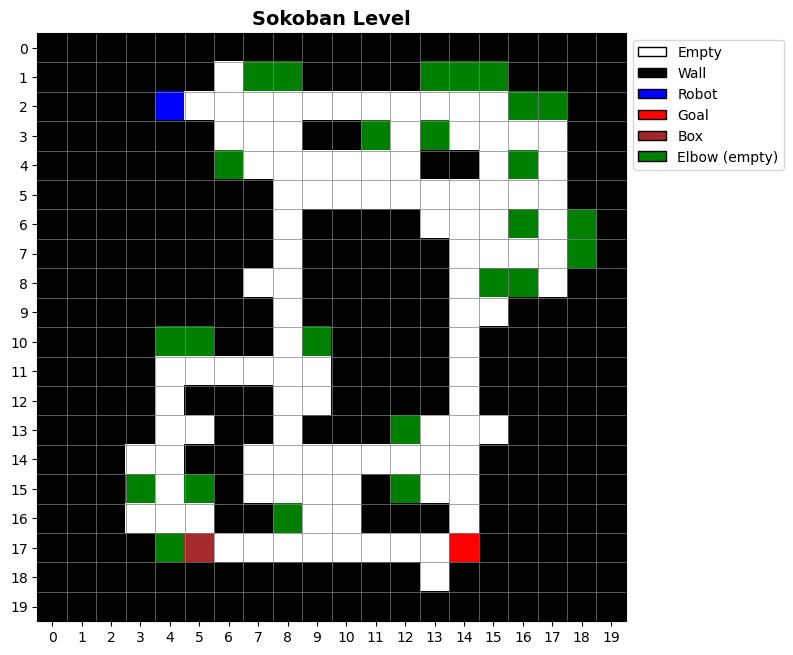

In [85]:
# Generate a level and the corresponding problem
sokoban_level = generate_maze(20, 20, erosion=True)
stringified_level = maze_to_string(sokoban_level)
sokoban_problem = create_sokoban_problem(stringified_level, with_axioms=False)

pretty_print(sokoban_level)
plot_level(sokoban_level)

# Solve the problem
with OneshotPlanner(problem_kind=sokoban_problem.kind) as planner:
    result = planner.solve(sokoban_problem) # , output_stream=sys.stdout
    if result.status in unified_planning.engines.results.POSITIVE_OUTCOMES:
        print(f"{planner.name} found this plan:")
        print(result.plan)
    else:
        print("No plan found.")